# Adding CRS metadata to IMAU-FDM post-processed output

The post-processed output files on the FGRN055 grid need CF-compliant CRS metadata
so that users can:
- correctly interpret the `rlat`/`rlon` grid axes
- reproject to other coordinate systems without needing the mask file
- open files directly in QGIS, GDAL, or with `xarray` + `rioxarray`

**Key finding:** The `X`/`Y` arrays in `FGRN055_Masks.nc` match **EPSG:3413**
(WGS 84 / NSIDC Sea Ice Polar Stereographic North) with zero residuals.
The global attribute text in the mask file claiming a different central meridian (−39°)
and standard parallel (71°) is incorrect.

This notebook:
1. Shows what is missing before the update
2. Runs `add_crs_metadata.py` on all post-process files
3. Verifies the new metadata
4. Demonstrates plotting in multiple projections using the new CRS info

In [1]:
import os
# Must be set before netCDF4/HDF5 is imported.
# Required on NFS filesystems where HDF5 file locking is unreliable.
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import sys
import subprocess
from pathlib import Path

import numpy as np
import netCDF4 as nc
import xarray as xr
import pyproj
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Paths
POSTPROCESS_DIR  = Path('/home/nld4814/scratch/run_FGRN055-era055_1939-2023/post-process')
MASK_FILE        = Path('/home/nld4814/perm/code/IMAU-FDM/reference/FGRN055/FGRN055_Masks.nc')
EXAMPLE_FILE     = POSTPROCESS_DIR / 'FDM_Runoff_FGRN055_1939-2023_10day.nc'
POSTPROCESS_CODE = Path('/home/nld4814/perm/code/IMAU-FDM/post-process')

sys.path.insert(0, str(POSTPROCESS_CODE))

In [10]:
ds = xr.open_dataset(EXAMPLE_FILE)

ds

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 3081, rlat: 566, rlon: 438)
Coordinates:
  * time     (time) float64 25kB 1.94e+03 1.94e+03 ... 2.024e+03 2.024e+03
  * rlat     (rlat) float32 2kB 0.0 1.0 2.0 3.0 4.0 ... 562.0 563.0 564.0 565.0
  * rlon     (rlon) float32 2kB 0.0 1.0 2.0 3.0 4.0 ... 434.0 435.0 436.0 437.0
    lat      (rlat, rlon) float32 992kB ...
    lon      (rlat, rlon) float32 992kB ...
Data variables:
    Runoff   (time, rlat, rlon) float32 3GB ...
    crs      int32 4B ...
    x        (rlat, rlon) float32 992kB ...
    y        (rlat, rlon) float32 992kB ...
Attributes:
    title:             IMAU-FDM gridded output: Runoff
    source:            IMAU-FDM version 1.2+
    domain:            FGRN055
    institution:       IMAU, Utrecht University
    time_aggregation:  10day
    Conventions:       CF-1.8
    history:           Created on 2026-02-03T14:48:54.158830\n2026-03-02T09:2...

## 1. Before: what CRS information is present?

In [28]:
def summarise_crs_state(filepath):
    """Print a concise summary of CRS-related content in a file."""
    with xr.open_dataset(filepath) as ds:
        print(f'File: {Path(filepath).name}')
        print(f'  Conventions : {ds.attrs.get("Conventions", "(missing)")}')
        print()
        print('  Variables:')
        all_vars = {**dict(ds.coords), **dict(ds.data_vars)}
        for name, var in all_vars.items():
            gm    = var.attrs.get('grid_mapping', '(missing)')
            coord = var.attrs.get('coordinates',  '(missing)')
            sname = var.attrs.get('standard_name', '(missing)')
            units = var.attrs.get('units', '(missing)')
            print(f'    {name:12s}  dims={str(var.dims):30s}  '
                  f'grid_mapping={gm}  coordinates={coord}  standard_name={sname}  units={units}')
        print()
        grid_vars = [n for n in all_vars if n in ('crs', 'rotated_pole', 'grid_mapping')]
        print(f'  Grid mapping variable : {", ".join(grid_vars) if grid_vars else "(none)"}')

summarise_crs_state(EXAMPLE_FILE)

File: FDM_Runoff_FGRN055_1939-2023_10day.nc
  Conventions : CF-1.8

  Variables:
    lat           dims=('rlat', 'rlon')                grid_mapping=(missing)  coordinates=(missing)  standard_name=latitude  units=degrees_north
    lon           dims=('rlat', 'rlon')                grid_mapping=(missing)  coordinates=(missing)  standard_name=longitude  units=degrees_east
    time          dims=('time',)                       grid_mapping=(missing)  coordinates=(missing)  standard_name=(missing)  units=years
    rlat          dims=('rlat',)                       grid_mapping=(missing)  coordinates=(missing)  standard_name=(missing)  units=1
    rlon          dims=('rlon',)                       grid_mapping=(missing)  coordinates=(missing)  standard_name=(missing)  units=1
    Runoff        dims=('time', 'rlat', 'rlon')        grid_mapping=crs  coordinates=(missing)  standard_name=(missing)  units=mm w.e.
    crs           dims=()                              grid_mapping=(missing)  coor

## 2. Verify EPSG:3413 against mask X/Y

Before updating the files, confirm that the mask file's `X`/`Y` arrays
are consistent with EPSG:3413.

In [29]:
with nc.Dataset(MASK_FILE) as ds:
    lat  = ds.variables['lat'][:]
    lon  = ds.variables['lon'][:]
    X_km = ds.variables['X'][:]
    Y_km = ds.variables['Y'][:]

crs_3413    = pyproj.CRS.from_epsg(3413)
transformer = pyproj.Transformer.from_crs('EPSG:4326', crs_3413, always_xy=True)
x_proj, y_proj = transformer.transform(lon, lat)   # metres

dx = x_proj / 1000 - X_km
dy = y_proj / 1000 - Y_km

print('EPSG:3413 vs mask X/Y residuals:')
print(f'  ΔX  mean={dx.mean():.4f} km   std={dx.std():.6f} km   max|ΔX|={np.abs(dx).max():.6f} km')
print(f'  ΔY  mean={dy.mean():.4f} km   std={dy.std():.6f} km   max|ΔY|={np.abs(dy).max():.6f} km')
print()
print('CRS definition:', crs_3413.name)

EPSG:3413 vs mask X/Y residuals:
  ΔX  mean=0.0000 km   std=0.000029 km   max|ΔX|=0.000125 km
  ΔY  mean=-0.0000 km   std=0.000076 km   max|ΔY|=0.000251 km

CRS definition: WGS 84 / NSIDC Sea Ice Polar Stereographic North


## 3. Run the update on all post-process files

The script runs in a **subprocess** so it starts with no open HDF5 file handles.
Calling `add_crs_to_all_files()` directly in the notebook would fail for any file
already opened above (e.g. `EXAMPLE_FILE`), because HDF5 tracks open file IDs
within the process and conflicts with the `r+` open even after `close()`.

In [30]:
result = subprocess.run(
    ['python3', str(POSTPROCESS_CODE / 'add_crs_metadata.py')],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:\n', result.stderr)
    raise RuntimeError('add_crs_metadata.py failed')

Loading X/Y from mask file ...
Processing 21 file(s) ...

  FDM_FirnAir_FGRN055_1939-2023_10day_detrended.nc
    done.
  FDM_Rho0_FGRN055_1939-2023_10day.nc
    done.
  FDM_Runoff_FGRN055_1939-2023_10day.nc
    done.
  FDM_T10m_FGRN055_1939-2023_2Ddetail.nc
    done.
  FDM_TotLwc_FGRN055_1939-2023_10day.nc
    done.
  FDM_h_surf_FGRN055_1939-2023_10day_detrended.nc
    done.
  FDM_icemass_FGRN055_1939-2023_10day.nc
    done.
  FDM_rain_FGRN055_1939-2023_10day.nc
    done.
  FDM_refreeze_FGRN055_1939-2023_10day.nc
    done.
  FDM_solin_FGRN055_1939-2023_10day.nc
    done.
  FDM_surfmelt_FGRN055_1939-2023_10day.nc
    done.
  FDM_vacc_FGRN055_1939-2023_10day.nc
    done.
  FDM_vbouy_FGRN055_1939-2023_10day.nc
    done.
  FDM_vfc_FGRN055_1939-2023_10day.nc
    done.
  FDM_vice_FGRN055_1939-2023_10day.nc
    done.
  FDM_vmelt_FGRN055_1939-2023_10day.nc
    done.
  FDM_vsnd_FGRN055_1939-2023_10day.nc
    done.
  FDM_vsub_FGRN055_1939-2023_10day.nc
    done.
  FDM_vtotal_FGRN055_1939-2023_10

## 4. After: verify the new metadata

In [31]:
summarise_crs_state(EXAMPLE_FILE)

File: FDM_Runoff_FGRN055_1939-2023_10day.nc
  Conventions : CF-1.8

  Variables:
    lat           dims=('rlat', 'rlon')                grid_mapping=(missing)  coordinates=(missing)  standard_name=latitude  units=degrees_north
    lon           dims=('rlat', 'rlon')                grid_mapping=(missing)  coordinates=(missing)  standard_name=longitude  units=degrees_east
    time          dims=('time',)                       grid_mapping=(missing)  coordinates=(missing)  standard_name=(missing)  units=years
    rlat          dims=('rlat',)                       grid_mapping=(missing)  coordinates=(missing)  standard_name=(missing)  units=1
    rlon          dims=('rlon',)                       grid_mapping=(missing)  coordinates=(missing)  standard_name=(missing)  units=1
    Runoff        dims=('time', 'rlat', 'rlon')        grid_mapping=crs  coordinates=(missing)  standard_name=(missing)  units=mm w.e.
    crs           dims=()                              grid_mapping=(missing)  coor

In [32]:
# Show the full crs variable attributes
with xr.open_dataset(EXAMPLE_FILE) as ds:
    print('crs variable attributes:')
    for attr, val in ds['crs'].attrs.items():
        if attr == 'crs_wkt':
            val = val[:80] + ' ...'
        print(f'  {attr:40s} = {val}')

crs variable attributes:
  standard_parallel                        = 70.0
  inverse_flattening                       = 298.257223563
  straight_vertical_longitude_from_pole    = -45.0
  false_easting                            = 0.0
  false_northing                           = 0.0
  semi_major_axis                          = 6378137.0
  latitude_of_projection_origin            = 90.0
  epsg_code                                = EPSG:3413
  grid_mapping_name                        = polar_stereographic
  crs_wkt                                  = PROJCS["WGS 84 / NSIDC Sea Ice Polar Stereographic North",GEOGCS["WGS 84",DATUM[ ...


In [33]:
# Show x/y coordinate shape and range
with xr.open_dataset(EXAMPLE_FILE) as ds:
    x = ds['x'].values
    y = ds['y'].values
    print(f'x shape: {x.shape},  range: [{x.min()/1e3:.1f}, {x.max()/1e3:.1f}] km')
    print(f'y shape: {y.shape},  range: [{y.min()/1e3:.1f}, {y.max()/1e3:.1f}] km')

x shape: (566, 438),  range: [-996.0, 1803.8] km
y shape: (566, 438),  range: [-3717.7, -248.2] km


## 5. Demo: open with xarray and plot in multiple projections

We use a single summer time step of Runoff as the example field.

In [34]:
with xr.open_dataset(EXAMPLE_FILE) as ds:
    # Pick a summer time step with significant runoff (~July 2012, extreme melt year)
    t_idx = int(np.argmin(np.abs(ds.time.values - 2012.54)))
    print(f'Plotting time index {t_idx}: fractional year {ds.time.values[t_idx]:.4f}')

    runoff = ds['Runoff'].isel(time=t_idx).values
    lat_2d = ds['lat'].values
    lon_2d = ds['lon'].values
    x_2d   = ds['x'].values   # metres, EPSG:3413
    y_2d   = ds['y'].values

# Mask zeros for cleaner display
runoff_masked = np.where(runoff > 0, runoff, np.nan)  

Plotting time index 2661: fractional year 2012.5328


/etc/ecmwf/ssd/ssd1/tmpdirs/nld4814.740818.20260302_140319.914/ipykernel_829735/1869566469.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


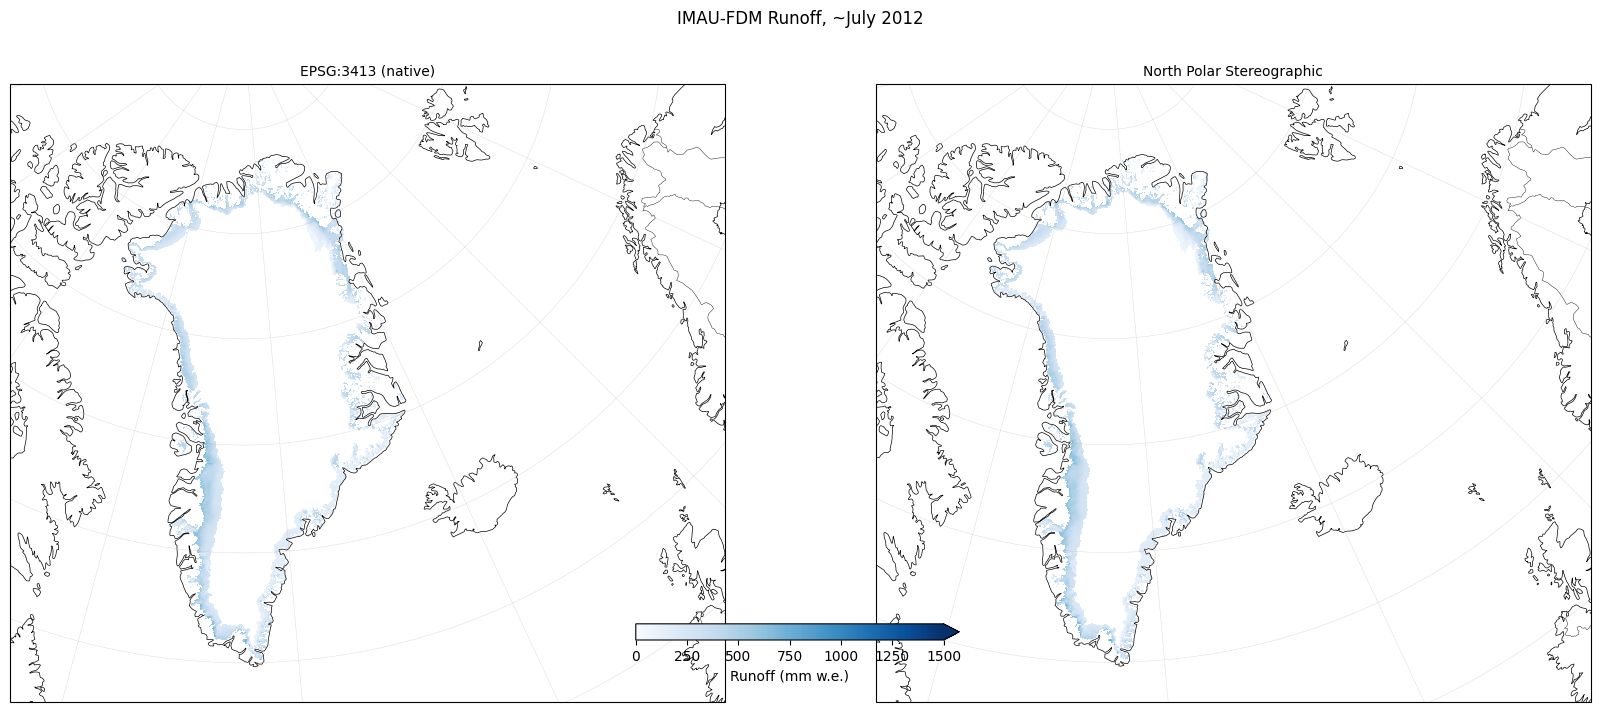

In [49]:
# Native EPSG:3413 projection for cartopy
native_proj = ccrs.Stereographic(
    central_latitude=90,
    central_longitude=-45,
    true_scale_latitude=70,
)

projections = [
    ('EPSG:3413 (native)',          native_proj,                                 x_2d,   y_2d,   'xy'),
    ('North Polar Stereographic',   ccrs.NorthPolarStereo(central_longitude=-45), lon_2d, lat_2d, 'lonlat')
]

cmap = plt.cm.Blues
norm = mcolors.LogNorm(vmin=1, vmax=200)

fig = plt.figure(figsize=(18, 7))
all_axes = []

for i, (title, proj, coord1, coord2, mode) in enumerate(projections):
    ax = fig.add_subplot(1, 2, i + 1, projection=proj)
    all_axes.append(ax)

    if mode == 'xy':
        pcm = ax.pcolormesh(coord1, coord2, runoff_masked,
                            transform=native_proj, cmap=cmap, vmin=0,vmax=1500)
    else:
        pcm = ax.pcolormesh(coord1, coord2, runoff_masked,
                            transform=ccrs.PlateCarree(), cmap=cmap, vmin=0,vmax=1500)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_extent([-65, 0, 58, 86], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=10)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)

fig.colorbar(pcm, ax=all_axes, orientation='horizontal',
             label='Runoff (mm w.e.)', extend='max', fraction=0.03, pad=0.04)
fig.suptitle('IMAU-FDM Runoff, ~July 2012', y=1.01)
plt.tight_layout()
plt.show()

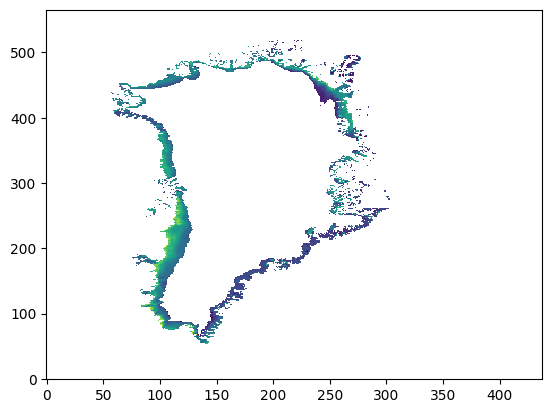

In [26]:
ds = xr.open_dataset(EXAMPLE_FILE)
plt.pcolormesh(ds.rlon,ds.rlat,runoff_masked)

In [ ]:
# Read the CRS back from the file via pyproj and confirm it round-trips
with xr.open_dataset(EXAMPLE_FILE) as ds:
    wkt = ds['crs'].attrs['crs_wkt']

crs_from_file = pyproj.CRS.from_wkt(wkt)
print('CRS read back from file WKT:')
print(f'  Name    : {crs_from_file.name}')
print(f'  EPSG    : {crs_from_file.to_epsg()}')
print(f'  Matches EPSG:3413: {crs_from_file.equals(pyproj.CRS.from_epsg(3413))}')

## Summary

Every file in the post-process directory now contains:

| Added | Purpose |
|---|---|
| `crs` scalar variable | Machine-readable CRS definition (CF + WKT) |
| `x`, `y` (rlat × rlon, metres) | Native EPSG:3413 projected coordinates |
| `grid_mapping = "crs"` on data vars | Links data to the CRS |
| `coordinates = "lat lon"` on data vars | Links data to geographic auxiliary coords |
| `standard_name` on `lat`, `lon` | CF compliance |
| `axis`, `units` on `rlat`, `rlon` | Clarifies these are grid indices, not degrees |
| `Conventions = CF-1.8` | Updated convention version |

**Note on the mask file global attribute:** the text `Map Reference Longitude: -39.0 ... Map Second Reference Latitude: 71.0` is incorrect — the actual CRS is EPSG:3413 (central meridian −45°, standard parallel 70°).